### Filtering Service-B Assessment

This notebook evaluates Filter-B decision correctness over a seven-day hourly testing window starting March 21, 2026 (UTC).  
  
Manual validation samples per run are used to check whether events are correctly passed or correctly dropped.   
   
The data comes from a pre-filled synthetic run-log style dataset in `evaluation/data/filter_b_runs_2026-03-21_to_2026-03-27.csv` with TP/TN/FP/FN and throughput fields.

In [3]:
from pathlib import Path
import pandas as pd

csv_path = Path('../data/filter_b_runs_2026-03-21_to_2026-03-27.csv')
df = pd.read_csv(csv_path)
df['run_started_at_utc'] = pd.to_datetime(df['run_started_at_utc'], utc=True)

window_start = pd.Timestamp('2026-03-21T00:00:00Z')
window_end = pd.Timestamp('2026-03-28T00:00:00Z')
window = df[(df['run_started_at_utc'] >= window_start) & (df['run_started_at_utc'] < window_end)].copy()

expected_hourly_runs = 7 * 24
observed_runs = len(window)
coverage_pct = (observed_runs / expected_hourly_runs) * 100 if expected_hourly_runs else 0

avg_correctness = window['decision_correctness_pct'].mean()
weighted_correctness = (window['manual_correct_count'].sum() / window['manual_sample_size'].sum()) * 100
min_correctness = window['decision_correctness_pct'].min()
max_correctness = window['decision_correctness_pct'].max()

fp_rate = (window['false_positive'].sum() / window['manual_sample_size'].sum()) * 100
fn_rate = (window['false_negative'].sum() / window['manual_sample_size'].sum()) * 100

throughput_mean = window['throughput_events_per_sec'].mean()
throughput_p95 = window['throughput_events_per_sec'].quantile(0.95)

summary = pd.DataFrame([
    {
        'window_start_utc': '2026-03-21',
        'window_days': 7,
        'runs_observed': observed_runs,
        'runs_expected_hourly': expected_hourly_runs,
        'coverage_pct': round(coverage_pct, 2),
        'avg_decision_correctness_pct': round(avg_correctness, 2),
        'weighted_decision_correctness_pct': round(weighted_correctness, 2),
        'min_correctness_pct': round(min_correctness, 2),
        'max_correctness_pct': round(max_correctness, 2),
        'false_positive_rate_pct': round(fp_rate, 2),
        'false_negative_rate_pct': round(fn_rate, 2),
        'throughput_mean_eps': round(throughput_mean, 2),
        'throughput_p95_eps': round(throughput_p95, 2)
    }
])
summary

,window_start_utc,window_days,runs_observed,runs_expected_hourly,coverage_pct,avg_decision_correctness_pct,weighted_decision_correctness_pct,min_correctness_pct,max_correctness_pct,false_positive_rate_pct,false_negative_rate_pct,throughput_mean_eps,throughput_p95_eps
0,2026-03-21,7,168,168,100.0,81.91,81.93,77.36,87.5,9.36,8.72,305.11,621.83


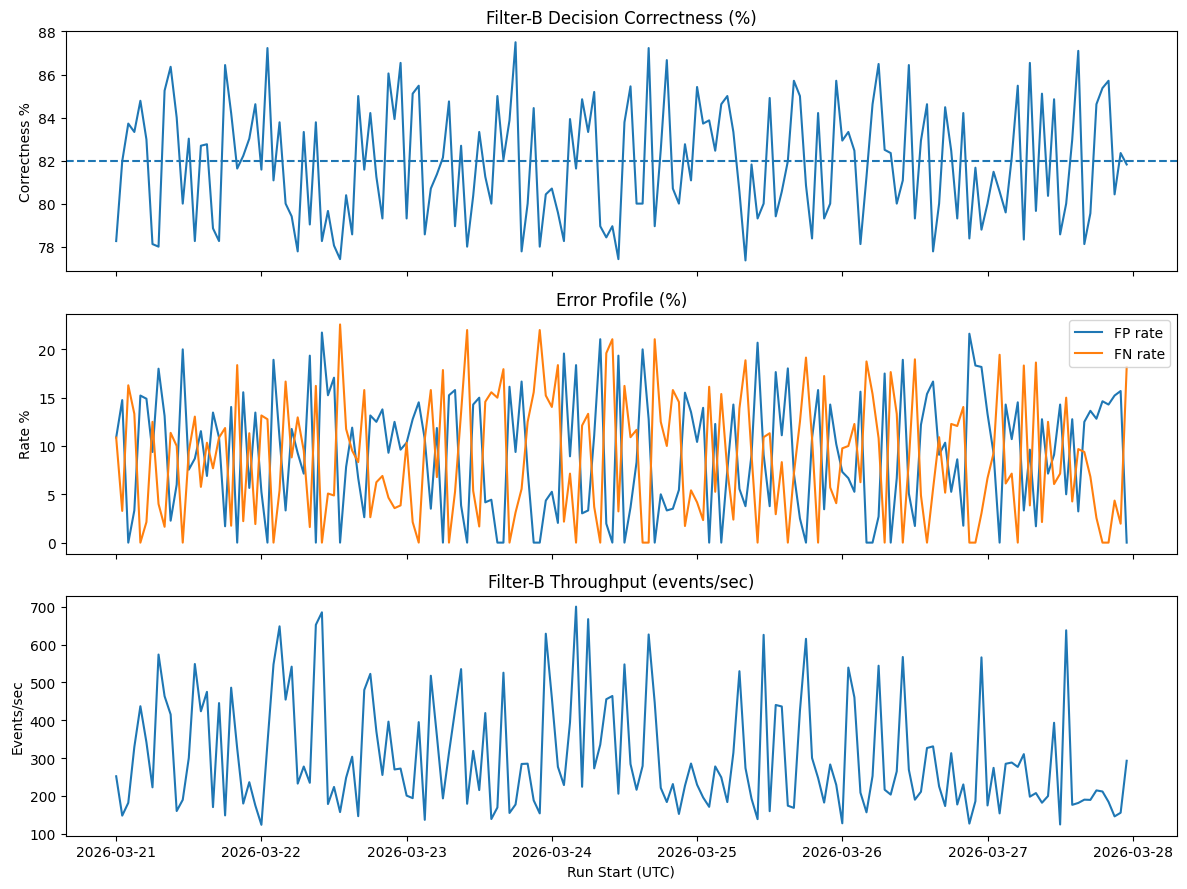

In [4]:
import matplotlib.pyplot as plt

plot_df = window.sort_values('run_started_at_utc').copy()

fig, axes = plt.subplots(3, 1, figsize=(12, 9), sharex=True)

axes[0].plot(plot_df['run_started_at_utc'], plot_df['decision_correctness_pct'])
axes[0].axhline(82, linestyle='--')
axes[0].set_title('Filter-B Decision Correctness (%)')
axes[0].set_ylabel('Correctness %')

axes[1].plot(plot_df['run_started_at_utc'], plot_df['false_positive_rate_pct'], label='FP rate')
axes[1].plot(plot_df['run_started_at_utc'], plot_df['false_negative_rate_pct'], label='FN rate')
axes[1].set_title('Error Profile (%)')
axes[1].set_ylabel('Rate %')
axes[1].legend()

axes[2].plot(plot_df['run_started_at_utc'], plot_df['throughput_events_per_sec'])
axes[2].set_title('Filter-B Throughput (events/sec)')
axes[2].set_ylabel('Events/sec')
axes[2].set_xlabel('Run Start (UTC)')

plt.tight_layout()
plt.show()